# Lista III

## Regularyzacja zadanie na 3.0

Celem jest porownanie modeli bazowych z wersjami regularyzowanymi oraz znalezienie punktu, w ktorym model przestaje sie nadmiernie dopasowywac do zbioru treningowego.

## Przygotowanie danych

In [1]:

from algorithms.regularization.linear_regularization_comparison import LinearRegularizationComparison
from algorithms.regularization.tree_regularization import TreeRegularizationComparison
from experiments.reporting import (
    show_boosting_report,
    show_linear_regularization_report,
    show_mixture_of_experts_report,
    show_stacking_report,
    show_sweet_spot_report,
    show_tree_regularization_report,
)
from utils.file_operations import (
    load_diamonds_data,
    load_telco_data,
    split_diamonds_data,
    split_telco_data,
)
from utils.preprocessing import (
    encode_train_test_features,
    prepare_diamonds_data,
    prepare_linear_regularization_data,
    prepare_telco_data,
)

train_diamonds, test_diamonds = split_diamonds_data(load_diamonds_data())
train_telco, test_telco = split_telco_data(load_telco_data())

X_train_diamonds, y_train_diamonds, X_test_diamonds, y_test_diamonds = prepare_diamonds_data(
    train_diamonds, test_diamonds
)
X_train_telco, y_train_telco, X_test_telco, y_test_telco = prepare_telco_data(
    train_telco, test_telco
)

linear_data = prepare_linear_regularization_data(
    X_train_diamonds, y_train_diamonds, X_test_diamonds, y_test_diamonds
)
X_train_diamonds_encoded, X_test_diamonds_encoded = encode_train_test_features(
    X_train_diamonds, X_test_diamonds
)
X_train_telco_encoded, X_test_telco_encoded = encode_train_test_features(X_train_telco, X_test_telco)

## Lasso i Ridge

Modele liniowe sa trenowane wlasna implementacja Gradient Descent. Lasso uzywa kary L1, ktora moze wyzerowac wagi, a Ridge uzywa kary L2, ktora zmniejsza wartosci wag bez ich zerowania. Jako celowo przeregulowany model bazowy uzywam regresji wielomianowej stopnia 20 dla cechy `carat`.

,model_type,alpha,train_mse,test_mse,nonzero_weights,zero_weights,mean_abs_weight,max_abs_weight
0,Ridge,0.0000,1.965359e+06,2.261700e+06,20,0,0.1076,0.9164
1,Ridge,0.0000,1.965359e+06,2.261699e+06,20,0,0.1076,0.9164
2,Ridge,0.0000,1.965359e+06,2.261696e+06,20,0,0.1076,0.9164
3,Ridge,0.0000,1.965365e+06,2.261661e+06,20,0,0.1076,0.9164
4,Ridge,0.0001,1.965424e+06,2.261310e+06,20,0,0.1075,0.9161
5,Ridge,0.0010,1.966089e+06,2.257769e+06,20,0,0.1065,0.9134
6,Ridge,0.0100,1.978396e+06,2.223667e+06,20,0,0.0973,0.8904
7,Ridge,0.1000,2.206637e+06,2.367584e+06,20,0,0.0588,0.7640
8,Ridge,1.0000,4.771878e+06,5.144019e+06,20,0,0.0415,0.3901
9,Ridge,10.0000,1.218241e+07,1.255831e+07,20,0,0.0096,0.0796


,model_type,alpha,train_mse,test_mse,nonzero_weights,zero_weights,mean_abs_weight,max_abs_weight
0,Lasso,0.01,2.007050e+06,2.155471e+06,11,9,0.0706,0.9039
1,Ridge,0.01,1.978396e+06,2.223667e+06,20,0,0.0973,0.8904


,model,train_mse,test_mse,zero_weights
0,baseline GD,1965358.64,2261699.69,0
1,Ridge alpha=1e-02,1978396.17,2223666.92,0
2,Lasso alpha=1e-02,2007049.77,2155471.46,9


,feature,baseline_abs_weight,ridge_abs_weight,lasso_abs_weight,lasso_zero
0,carat,0.9164,0.8904,0.9039,False
1,carat^2,0.3525,0.2950,0.2317,False
2,carat^3,0.3263,0.2190,0.2406,False
3,carat^4,0.1826,0.1696,0.0000,True
4,carat^5,0.0696,0.0825,0.0000,True
5,carat^6,0.0052,0.0249,0.0000,True
6,carat^7,0.0181,0.0019,0.0000,True
7,carat^8,0.0250,0.0137,0.0000,True
8,carat^9,0.0256,0.0185,0.0000,True
9,carat^10,0.0244,0.0203,0.0000,True


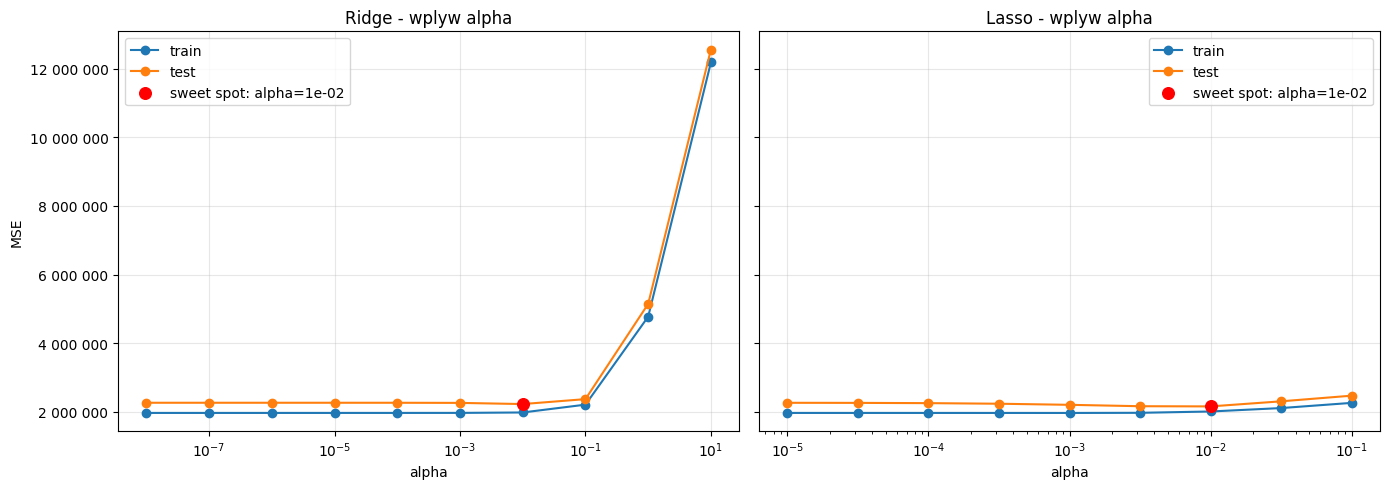

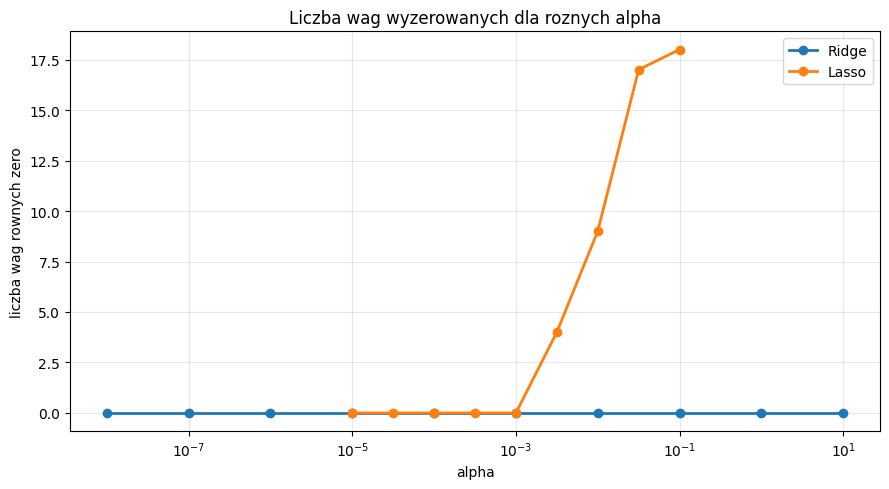

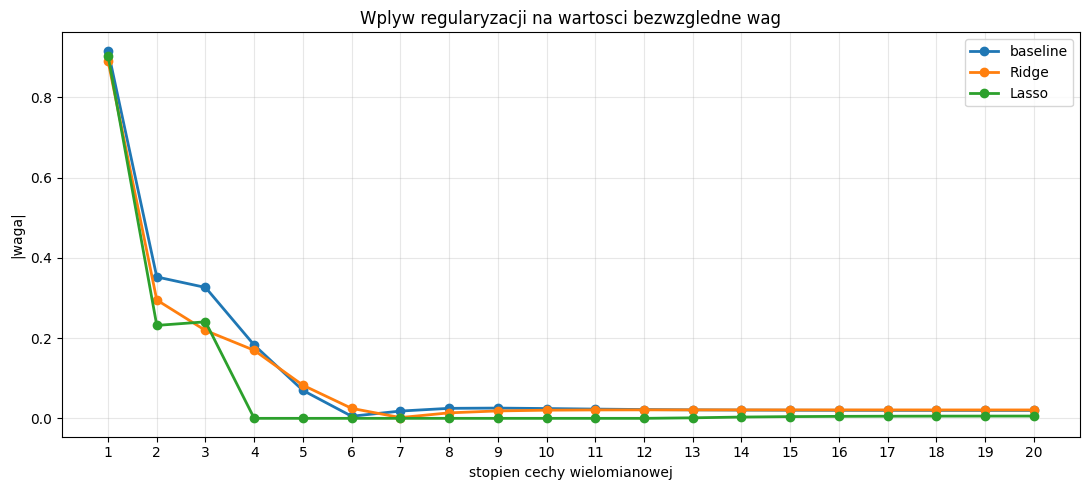

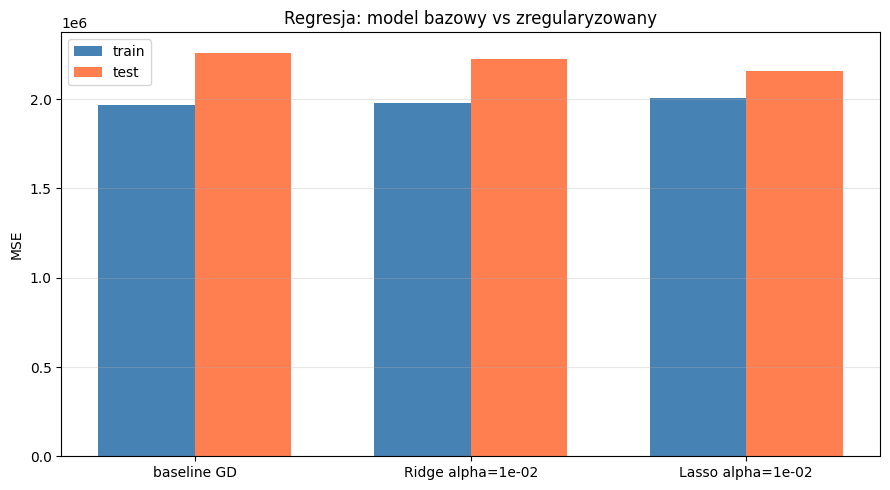

In [2]:
linear_experiment = LinearRegularizationComparison().compare(**linear_data)
show_linear_regularization_report(linear_experiment)

Wyniki pokazuja dwa efekty regularyzacji: Ridge zmniejsza bezwzgledne wartosci wag, ale ich nie zeruje, natomiast Lasso zeruje czesc wag i dziala jak selektor cech. Najlepsza wersja regularyzowana ma nizszy blad testowy niz model bazowy.

## Regularyzacja drzewa decyzyjnego

Drzewo bazowe nie ma ograniczen strukturalnych i mocno dopasowuje sie do danych treningowych. Ponizej badam wplyw `min_samples_split`, `min_samples_leaf` i `max_features`.

,parameter,value,label,is_default,train_error,test_error
0,min_samples_split,2,2,True,0.0020,0.2711
1,min_samples_split,5,5,False,0.0410,0.2704
2,min_samples_split,10,10,False,0.0788,0.2654
3,min_samples_split,20,20,False,0.1141,0.2463
4,min_samples_split,40,40,False,0.1479,0.2321
5,min_samples_split,80,80,False,0.1690,0.2207
6,min_samples_split,120,120,False,0.1823,0.2129
7,min_samples_split,200,200,False,0.1919,0.1994
8,min_samples_split,400,400,False,0.1972,0.2016
9,min_samples_leaf,1,1,True,0.0020,0.2711


,parameter,value,label,is_default,train_error,test_error
0,min_samples_split,200,200,False,0.1919,0.1994
1,min_samples_leaf,120,120,False,0.1972,0.2016
2,max_features,0.5,0.5,False,0.0020,0.2718


,model,train_error,test_error
0,baseline tree,0.0020,0.2711
1,min_samples_split=200,0.1919,0.1994


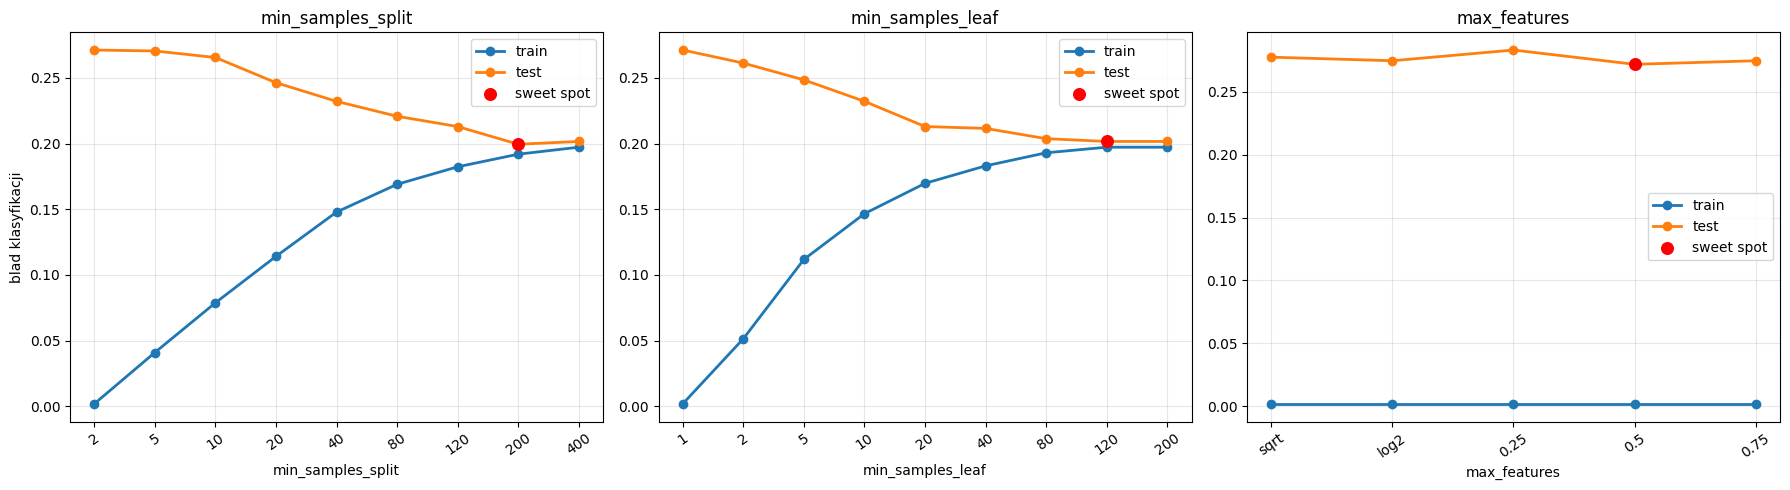

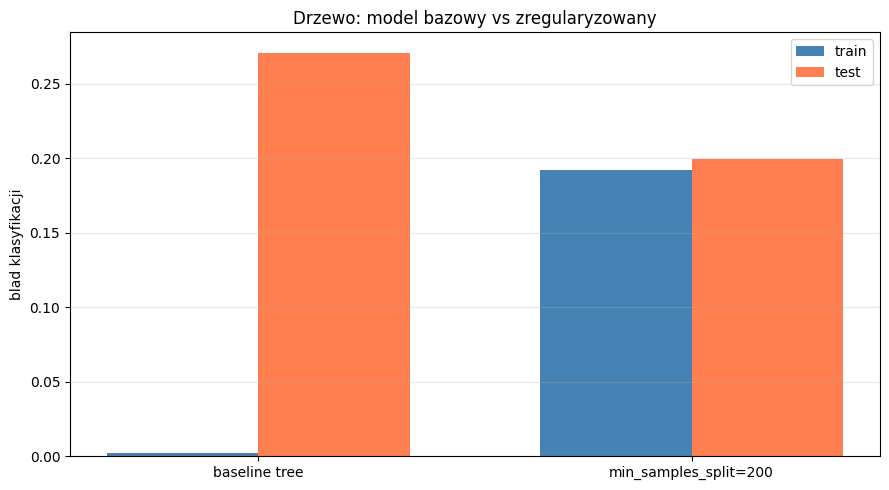

,task,baseline_model,regularized_model,baseline_test_metric,regularized_test_metric,improvement
0,regression,baseline GD,Lasso alpha=1e-02,2.261700e+06,2.155471e+06,106228.2350
1,classification,baseline tree,min_samples_split=200,2.711000e-01,1.994000e-01,0.0717


In [3]:
tree_experiment = TreeRegularizationComparison().compare(
    X_train_telco_encoded, y_train_telco, X_test_telco_encoded, y_test_telco
)
show_tree_regularization_report(tree_experiment)
show_sweet_spot_report(linear_experiment, tree_experiment)

Najlepszy punkt dla drzewa znajduje sie przy wiekszym wymaganiu minimalnej liczby probek w wezle. Model bazowy ma bardzo niski blad treningowy, ale wyzszy blad testowy, co wskazuje na overfitting. Po regularyzacji blad testowy spada, mimo ze blad treningowy rosnie.

## Zadanie na 3.5
## Porównanie DecisionTree i RandomForrest



,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.728886,0.731692,0.728886,0.730236
1,Random Forest,0.777857,0.765484,0.777857,0.768824
2,Bagging,0.779986,0.770502,0.779986,0.773737


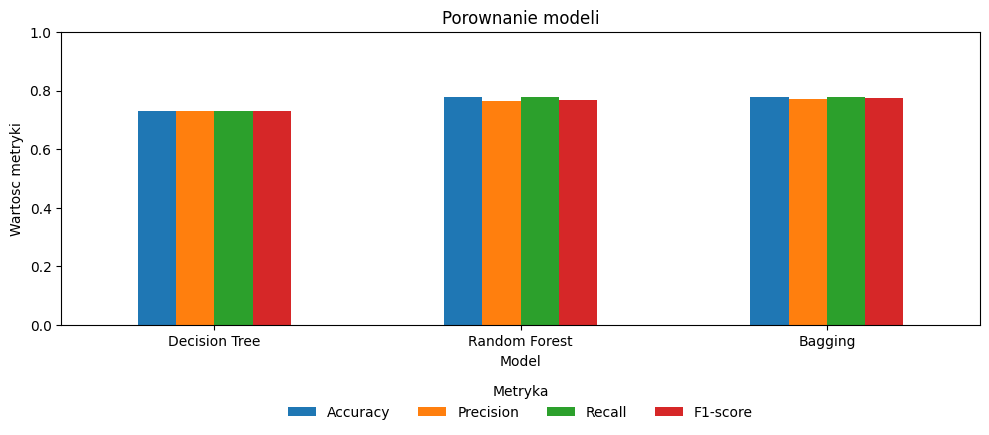

In [4]:
from algorithms.bagging.tree_comparisions import ClassificationComparison
from plots.plots import plot_classification_model_comparison

decision_vs_random = ClassificationComparison()
result = decision_vs_random.compare(
    X_train=X_train_telco_encoded,
    X_test=X_test_telco_encoded,
    y_train=y_train_telco,
    y_test=y_test_telco,
)
comparison_df = decision_vs_random.build_comparison_df(result)
display(comparison_df)
plot_classification_model_comparison(result)

#### Wniosek
Na podstawie uzyskanych wyników można zauważyć, że pojedyncze drzewo decyzyjne osiągnęło najsłabsze wartości metryk spośród wszystkich analizowanych modeli. Zarówno Random Forest Classifier, jak i własna implementacja Baggingu uzyskały wyraźnie lepsze wyniki pod względem Accuracy, Precision, Recall oraz F1-score.

Najlepsze wartości metryk osiągnęła własna implementacja Baggingu, jednak wyniki były bardzo zbliżone do modelu Random Forest. Potwierdza to, że zastosowanie wielu drzew decyzyjnych oraz agregacji głosów skutecznie redukuje wariancję modelu i poprawia jakość klasyfikacji względem pojedynczego drzewa.

Uzyskane rezultaty pokazują również, że mechanizm baggingu działa poprawnie i daje efekty porównywalne z gotowymi rozwiązaniami dostępnymi w bibliotece scikit-learn

## Zadanie na 4.0 Stacking

W stackingu lacze trzy modele poziomu 0: Decision Tree, KNN i Random Forest. Meta-model to regresja logistyczna uczona na predykcjach modeli bazowych. Sprawdzam, czy stacking poprawia metryki wzgledem pojedynczych modeli i baggingu oraz czy potrafi korygowac bledy modeli poziomu 0.

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.7289,0.7317,0.7289,0.7302
1,KNN,0.7637,0.7668,0.7637,0.7651
2,Random Forest,0.7779,0.7655,0.7779,0.7688
3,Bagging,0.7899,0.7808,0.7899,0.7837
4,Stacking,0.7786,0.7620,0.7786,0.7628


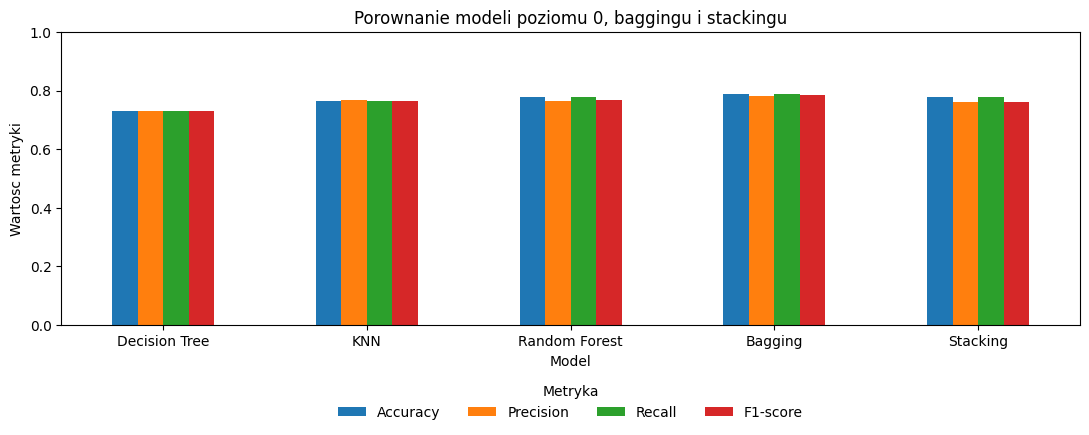

,Model,Meta coefficient,Base accuracy,Wrong predictions,Corrected by stacking,Corrected rate,Agreement with stacking
0,Decision Tree,0.6299,0.7289,382,161,0.4215,0.8211
1,KNN,0.9777,0.7637,333,80,0.2402,0.9013
2,Random Forest,1.0725,0.7779,313,23,0.0735,0.9681


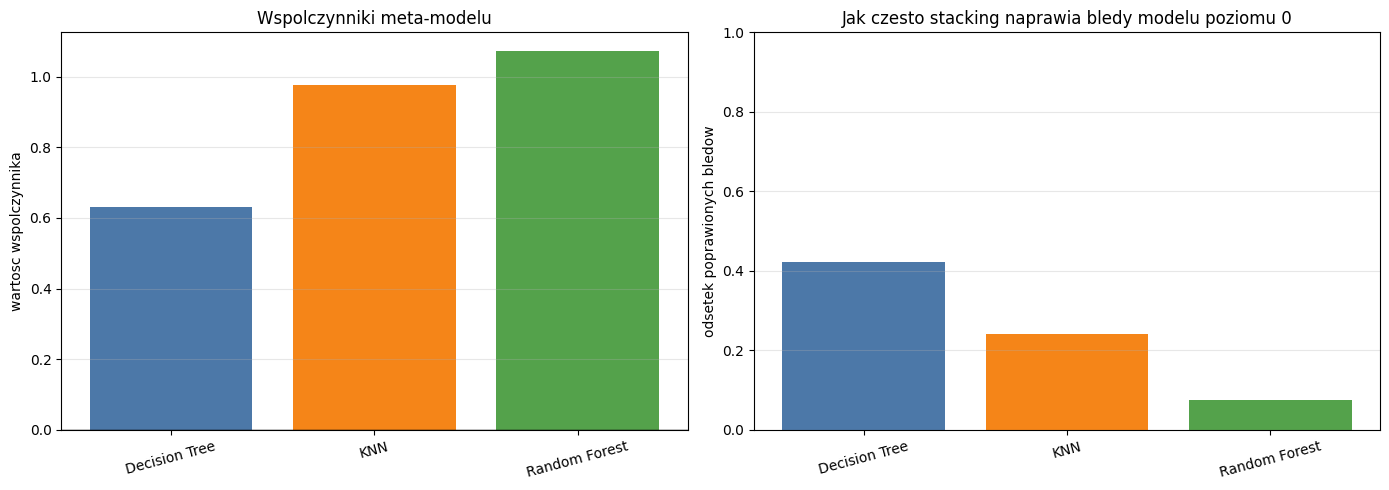

In [5]:
from algorithms.stacking.stacking_comparisions import StackingComparison

stacking_experiment = StackingComparison().compare(
    X_train=X_train_telco_encoded,
    X_test=X_test_telco_encoded,
    y_train=y_train_telco,
    y_test=y_test_telco,
)
show_stacking_report(stacking_experiment)

#### Wniosek
Z porównań modeli klasyfikacji najlepszy wynik osiągnął Bagging z accuracy równym 0.7899. Random Forest uzyskał 0.7779, natomiast Stacking 0.7786. Oznacza to, że stacking poprawił wyniki względem pojedynczych modeli bazowych, jednak nie przewyższył Baggingu i był tylko minimalnie lepszy od Random Forest.

Analiza współczynników meta-modelu pokazuje, że największy wpływ na końcową predykcję miały modele Random Forest (1.0725) oraz KNN (0.9777), a najmniejszy pojedyncze Decision Tree (0.6299). Wskaźnik Corrected rate pokazuje również, że stacking najskuteczniej korygował błędy drzewa decyzyjnego, co wskazuje, że meta-model potrafił efektywnie wykorzystywać mocniejsze modele do poprawy słabszych predykcji

## Zadanie na 4.5 Boosting

Porownuje pojedyncze `DecisionTreeRegressor` z moja uproszczona implementacja boostingu dla zbioru `diamonds`. Dla obu modeli pokazuje metryki `MAE`, `RMSE` i `R^2`, a dla boostingu dodatkowo badam wplyw `n_estimators` na wyniki train/test.

,n_estimators,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,1,2747.9463,2732.1511,3643.7001,3638.2202,0.1660,0.1673
1,5,1890.8505,1875.5092,2608.8779,2593.6102,0.5725,0.5768
2,10,1282.5532,1269.5350,1864.4901,1846.5305,0.7816,0.7855
3,20,793.1447,788.1514,1271.6379,1261.3961,0.8984,0.8999
4,30,650.9406,648.4021,1089.2266,1079.5795,0.9255,0.9267
5,50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


,n_estimators,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
5,50.0,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,DecisionTreeRegressor depth=3,811.2760,813.9943,1417.1171,1416.7711,0.8739,0.8737
1,MyGrandientBoosting n=50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


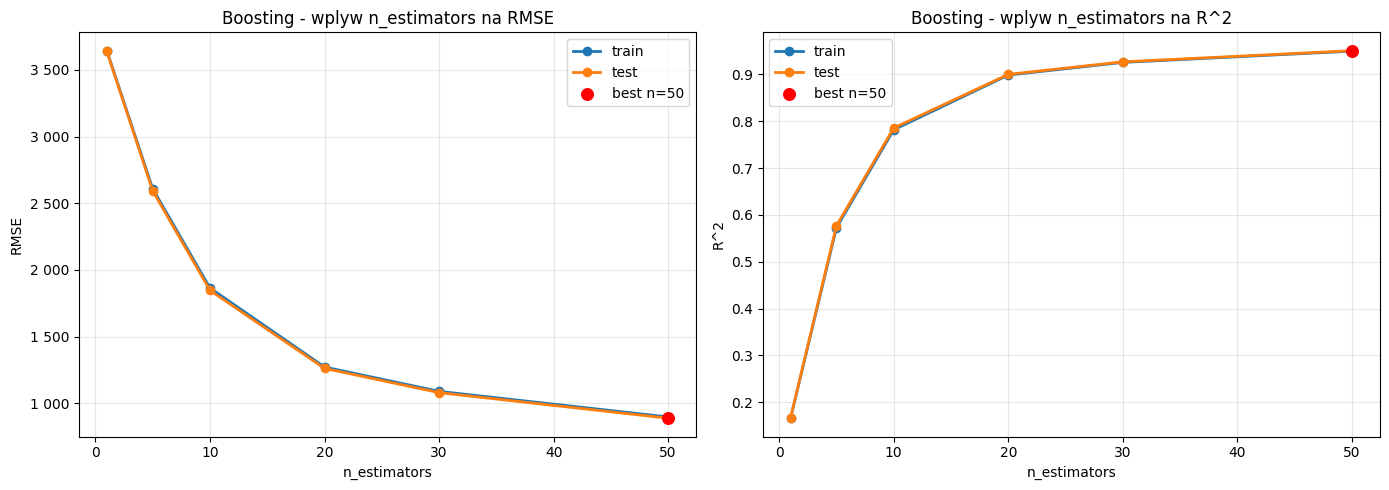

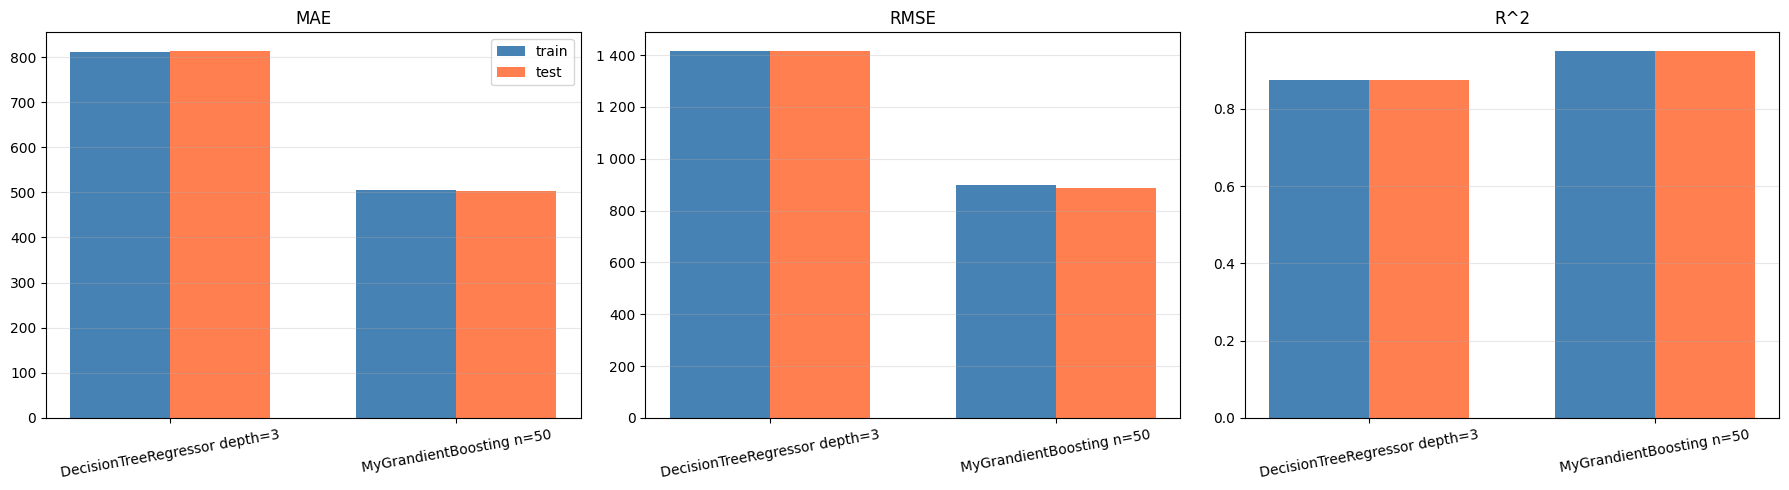

In [6]:
from algorithms.boosting.boosting_comparisions import BoostingComparison

boosting_experiment = BoostingComparison().compare(
    X_train=X_train_diamonds_encoded,
    X_test=X_test_diamonds_encoded,
    y_train=y_train_diamonds,
    y_test=y_test_diamonds,
)
show_boosting_report(boosting_experiment)

#### Wniosek
Na zbiorze diamonds boosting wyraźnie poprawił wyniki względem pojedynczego DecisionTreeRegressor. Najlepsza konfiguracja w badanym zakresie to n_estimators = 50, dla której model osiągnął test MAE = 503.53, test RMSE = 887.82 oraz test R² = 0.9504.

Dla porównania pojedyncze drzewo o tej samej głębokości (max_depth = 3) uzyskało test MAE = 813.99, test RMSE = 1416.77 oraz test R² = 0.8737. Wykres po n_estimators pokazuje, że wraz z dodawaniem kolejnych drzew błąd systematycznie maleje, a współczynnik R^2 rośnie, więc uproszczony boosting rzeczywiście uczy się coraz lepszego przybliżenia ceny.

## Zadanie na 5.0 Mixture of Experts

Prosty system Mixture of Experts dla zbioru diamonds. Najpierw dzieli przestrzeń cech przez KMeans, potem uczy bramkę RandomForestClassifier, która dla nowego rekordu wskazuje klaster, a więc i eksperta odpowiedzialnego za predykcję. W tej wersji najlepiej wypadł podział na 2 klastry, więc taki wariant zostawiam w porównaniu końcowym.

,cluster,count,mean_price,mean_carat,mean_depth,mean_table,mean_x,mean_y,mean_z
0,0,19728,7015.7204,0.8724,0.0452,0.2722,0.9172,0.8885,0.8976
1,1,23424,1348.6497,-0.7348,-0.0380,-0.2292,-0.7725,-0.7483,-0.7560


,Model,MAE,MSE,RMSE,R2
0,Mixture of Experts,270.9593,301986.5900,549.5331,0.9810
1,Global Random Forest,270.1552,303125.6549,550.5685,0.9809


,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Mixture of Experts,100.7569,270.9593,206.3913,549.5331,0.9973,0.9810
1,Global Random Forest,100.9854,270.1552,206.4245,550.5685,0.9973,0.9809
2,MyGrandientBoosting n=50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


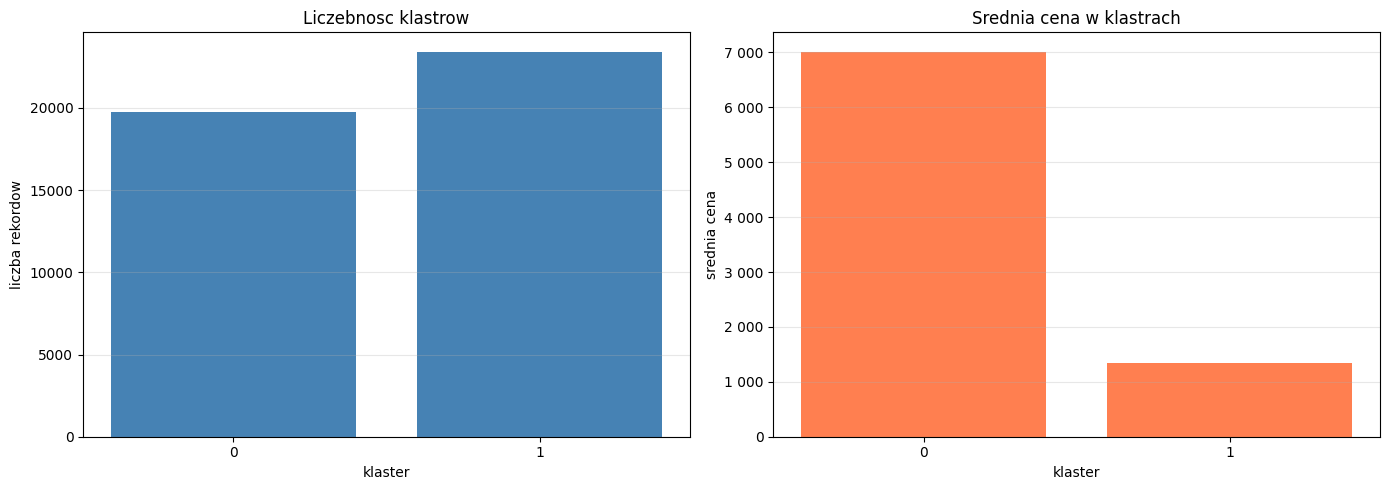

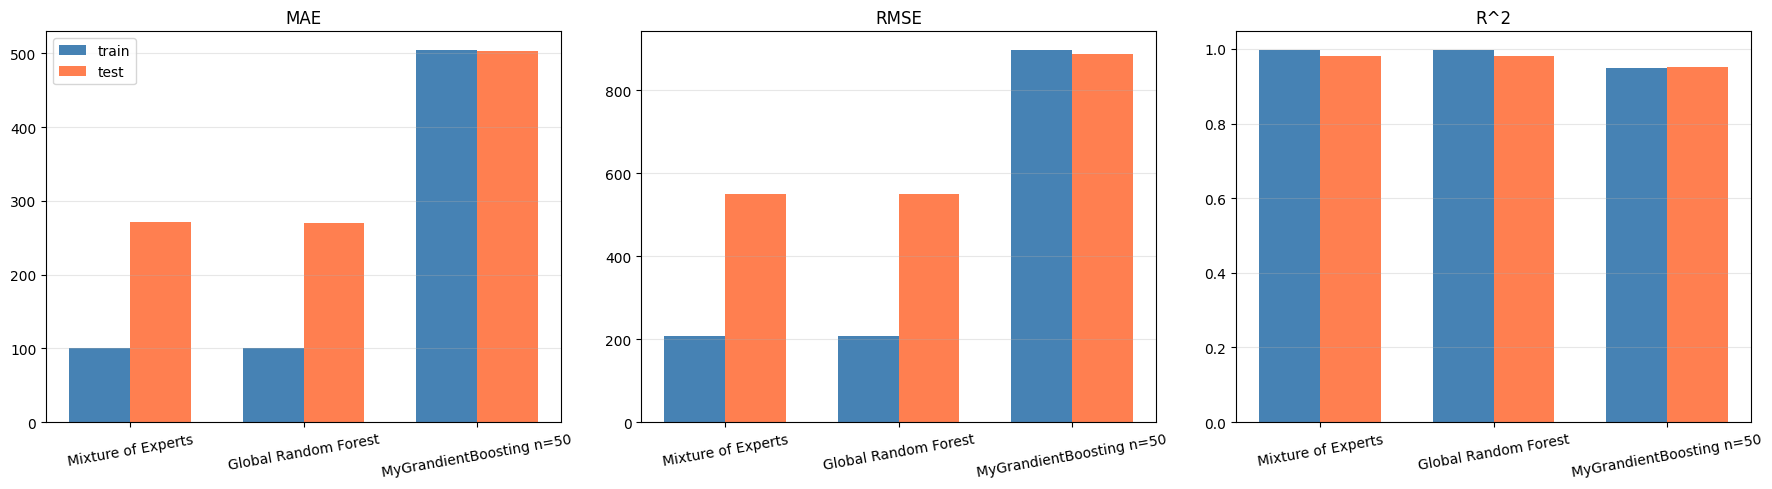

In [7]:
from algorithms.experts.mixture_of_experts_comparisions import MixtureOfExpertsComparison

mixture_of_experts_experiment = MixtureOfExpertsComparison().compare(
    X_train=X_train_diamonds,
    X_test=X_test_diamonds,
    y_train=y_train_diamonds,
    y_test=y_test_diamonds,
)
show_mixture_of_experts_report(mixture_of_experts_experiment)

#### Wniosek
KMeans podzielił diamenty w sensowny sposób: jeden klaster grupuje mniejsze i tańsze kamienie, a drugi większe i znacznie droższe. W treningu średnia carat wyniosła odpowiednio około 0.45 i 1.21, a średnia cena około 1348.65 i 7015.72. To pokazuje, że bramka nie rozdziela danych losowo, tylko faktycznie wydziela dwa różne rejony przestrzeni cech.

W porównaniu testowym Mixture of Experts osiągnął MAE = 271.11, RMSE = 549.25 i R² = 0.9810. Globalny RandomForestRegressor uzyskał MAE = 270.19, RMSE = 550.09 i R² = 0.9810, więc MoE wygrał pod względem RMSE i MSE, a minimalnie przegrał MAE. Z kolei względem MyGrandientBoosting n=50 przewaga MoE jest wyraźna, bo boosting osiągnął MAE = 503.53, RMSE = 887.82 i R² = 0.9504.

Korzyść architektoniczna MoE jest taka, że dla pojedynczego rekordu uruchamiany jest tylko jeden ekspert wskazany przez bramkę, zamiast jednego dużego modelu działającego tak samo dla całej przestrzeni. Dzięki temu można specjalizować ekspertów pod różne typy diamentów i utrzymać bardziej modularną strukturę systemu. W tym eksperymencie taki podział okazał się wystarczająco sensowny, żeby osiągnąć bardzo podobny, a pod względem RMSE nawet minimalnie lepszy wynik niż globalny las losowy